# Experiments

in this notebook we run all 3 models 

In [1]:
# add the directory to the path so we can import modules
import sys
import os
sys.path.append(os.path.abspath('..'))


In [2]:
import torch
import random
import numpy as np
import pandas as pd

from src.dataset import get_dataloaders, create_binary_dataset
from src.utils import train_model, logs_to_df, print_train_times, plot_curves, compare_models_latency
from src.models.lstm import BaselineLSTM
from src.models.reservoirs import RandomLSM, StructuredLSNN

In [3]:
# Setup device and seed for reproducibility

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Running on {DEVICE}")

SEED = 0

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED) 

Running on mps


In [4]:
create_binary_dataset('../data/raw', '../data/processed')

Processing ECG5000_TRAIN.txt...
  Saved to ../data/processed/BINARY_ECG5000_TRAIN.txt
  Stats: Healthy=292, Unhealthy=208, Total=500
Processing ECG5000_TEST.txt...
  Saved to ../data/processed/BINARY_ECG5000_TEST.txt
  Stats: Healthy=2627, Unhealthy=1873, Total=4500


In [5]:
# load the dataset
train_loader, test_loader = get_dataloaders('../data/processed', batch_size=64, processed=True)

# define the models
model_a = BaselineLSTM()
model_b = RandomLSM()
model_c = StructuredLSNN()

# train the models
model_a, hist_a = train_model(model_a, train_loader, test_loader, device=DEVICE, epochs=30, lr=0.001)
model_b, hist_b = train_model(model_b, train_loader, test_loader, device=DEVICE, epochs=30, lr=0.001)
model_c, hist_c = train_model(model_c, train_loader, test_loader, device=DEVICE, epochs=30, lr=0.001)




Starting training on mps...


Epochs:   3%|▎         | 1/30 [00:00<00:26,  1.11it/s]

Epoch [1/30], Loss: 0.6735, Test Acc: 86.07%


Epochs:   7%|▋         | 2/30 [00:01<00:19,  1.42it/s]

Epoch [2/30], Loss: 0.5485, Test Acc: 92.62%


...

Epoch [28/30], Loss: 0.4055, Test Acc: 89.58%


Epochs:  97%|█████████▋| 29/30 [01:39<00:03,  3.49s/it]

Epoch [29/30], Loss: 0.3935, Test Acc: 89.69%


Epochs: 100%|██████████| 30/30 [01:43<00:00,  3.44s/it]


Epoch [30/30], Loss: 0.3824, Test Acc: 89.71%
Training finished in 103.31 seconds.


In [6]:
MODEL_LOGS = [
    {"name": "BaselineLSTM", "history": hist_a},
    {"name": "RandomLSM", "history": hist_b},
    {"name": "StructuredLSNN", "history": hist_c},
]

BaselineLSTM: 17.3580539226532 s
RandomLSM: 79.52129697799683 s
StructuredLSNN: 103.30965399742126 s


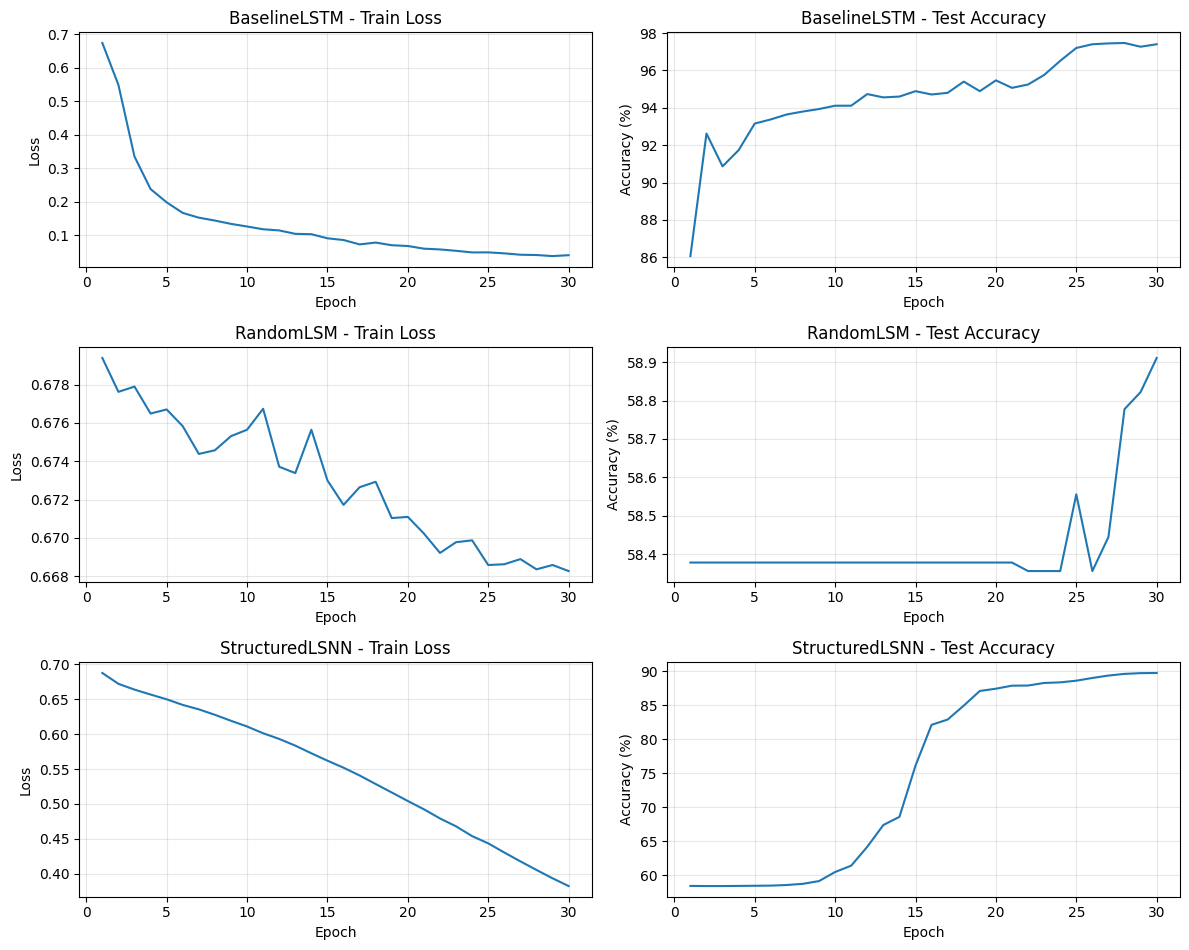

In [7]:
logs_to_df(MODEL_LOGS)
print_train_times(MODEL_LOGS)
plot_curves(MODEL_LOGS)

In [8]:
one_sample, _ = next(iter(test_loader))
one_sample = one_sample[0]  # [T, F] single entry

models = {
    "BaselineLSTM": model_a,
    "RandomLSM": model_b,
    "StructuredLSNN": model_c,
}
compare_models_latency(models, one_sample, device=DEVICE)

BaselineLSTM: 5.943 ms / sample
RandomLSM: 32.622 ms / sample
StructuredLSNN: 41.475 ms / sample
Fastest: BaselineLSTM


[('BaselineLSTM', 5.9429010399617255),
 ('RandomLSM', 32.622445253655314),
 ('StructuredLSNN', 41.47494565928355)]